In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor


file_path = 'test2.csv'
df = pd.read_csv(file_path)

# 1. Xử lý thời gian
if 'pickup_time' in df.columns:
    df['pickup'] = pd.to_datetime(df['pickup_time'])
    df['dropoff'] = pd.to_datetime(df['dropoff_time'])
elif 'tpep_pickup_datetime' in df.columns:
    df['pickup'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['dropoff'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Tính thời gian di chuyển (phút)
df['duration_min'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60

# Tạo biến Giờ để tính cao điểm
df['hour'] = df['pickup'].dt.hour

# Giờ cao điểm giả định
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7<=x<=9) or (16<=x<=19) else 0)

# Cuối tuần
df['is_weekend'] = df['pickup'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
print(f"   - Số chuyến cuối tuần: {df['is_weekend'].sum()}")
print(f"   - Số chuyến ngày thường: {len(df) - df['is_weekend'].sum()}")

# Lọc bỏ giá trị âm, quãng đường quá ngắn, thời gian quá ngắn
df_clean = df[
    (df['fare_amount'] > 2.5) & (df['fare_amount'] < 200) &
    (df['trip_distance'] > 0.1) &
    (df['duration_min'] > 1) & (df['duration_min'] < 180)
].copy()

df_model = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)
print(f"Dữ liệu sẵn sàng cho mô hình: {len(df_model)} dòng.")

>>> [1] ĐANG XỬ LÝ DỮ LIỆU...
✅ Đã thêm biến 'is_weekend'.
   - Số chuyến cuối tuần: 16078
   - Số chuyến ngày thường: 33922
Dữ liệu sẵn sàng cho mô hình: 5000 dòng.



>>> [2] THỐNG KÊ MÔ TẢ & TRỰC QUAN HÓA
                count       mean        std   min   25%     50%        75%  \
fare_amount    5000.0  19.305880  16.501427  3.70  9.30  13.500  21.900000   
trip_distance  5000.0   3.176486   4.148563  0.12  1.02   1.685   3.010000   
duration_min   5000.0  16.992813  13.344473  1.05  8.10  13.275  21.320833   

                      max  
fare_amount    134.600000  
trip_distance   28.160000  
duration_min   107.433333  

Đã loại bỏ các chuyến có giá cước > 40.80 USD
Số lượng mẫu còn lại: 4541


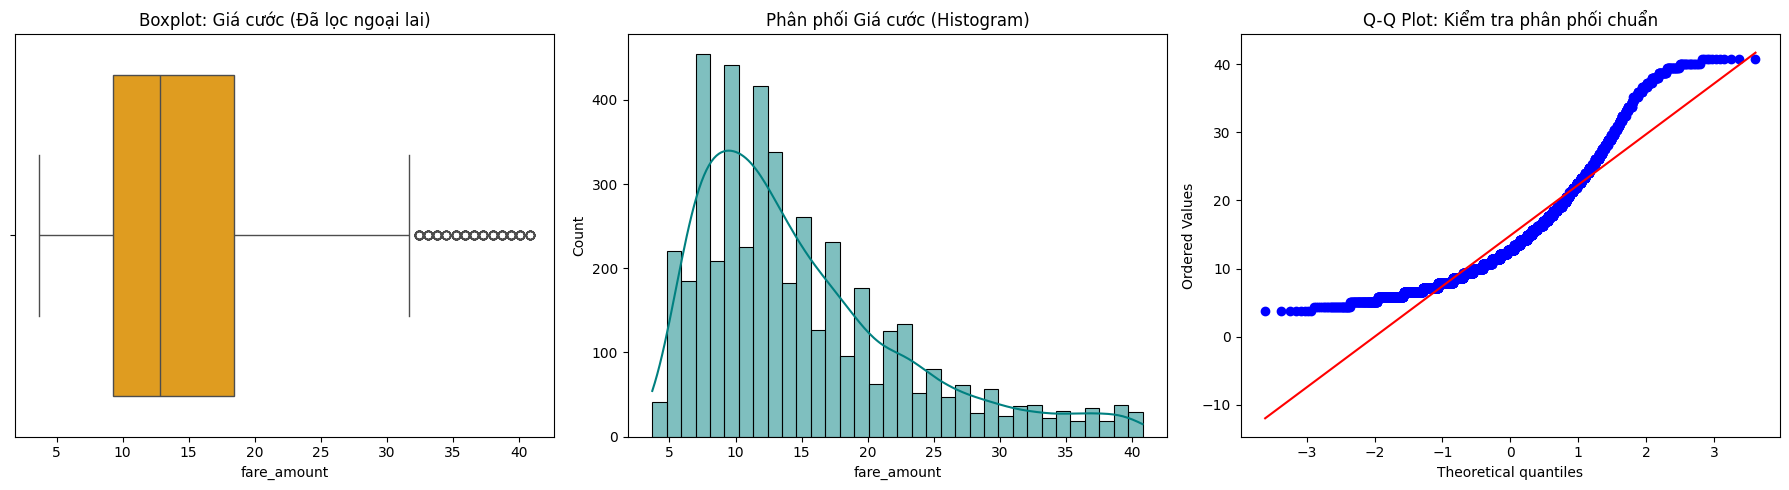

In [ ]:


# 1. Thống kê cơ bản
vars_to_check = ['fare_amount', 'trip_distance', 'duration_min']
print(df_model[vars_to_check].describe().T)

# 2. Xử lý ngoại lai cho biến Y (fare_amount) bằng IQR
Q1 = df_model['fare_amount'].quantile(0.25)
Q3 = df_model['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# Lọc bỏ ngoại lai
df_final = df_model[df_model['fare_amount'] <= upper_limit].copy()
print(f"\nĐã loại bỏ các chuyến có giá cước > {upper_limit:.2f} USD")
print(f"Số lượng mẫu còn lại: {len(df_final)}")

# 3. Vẽ biểu đồ phân phối (Histogram & Boxplot)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
sns.boxplot(x=df_final['fare_amount'], ax=ax[0], color='orange')
ax[0].set_title('Boxplot: Giá cước sau khi loại ngoại lai')

# Histogram
sns.histplot(df_final['fare_amount'], kde=True, ax=ax[1], color='teal')
ax[1].set_title('Phân phối Giá cước')

# Q-Q Plot (Kiểm tra tính chuẩn)
stats.probplot(df_final['fare_amount'], dist="norm", plot=ax[2])
ax[2].set_title('Q-Q Plot: Kiểm tra phân phối chuẩn')

plt.tight_layout()
plt.show()

In [ ]:


# Danh sách tất cả các biến dự kiến đưa vào mô hình
input_vars = ['fare_amount', 'trip_distance', 'duration_min', 'is_rush_hour', 'is_weekend']

# 1. Vẽ Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_final[input_vars].corr()

# Vẽ biểu đồ
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận Tương quan Pearson')

# [MỚI] Lưu biểu đồ thành file ảnh (png)
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Đã lưu ảnh thành công: correlation_matrix.png")

plt.show()

# [TÙY CHỌN] Nếu dùng Google Colab, dòng này sẽ tự động tải file về máy tính
'''try:
    from google.colab import files
    files.download('correlation_matrix.png')
except ImportError:
    pass # Nếu không phải Colab thì bỏ qua

# 2. Kiểm tra Đa cộng tuyến (VIF)
# Chỉ xét các biến độc lập (X)
#X_vif = df_final[['trip_distance', 'duration_min', 'is_rush_hour', 'is_weekend']]

# Lưu ý: Nên thêm hằng số để tính VIF chính xác hơn (đã bỏ comment dòng này)
#X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Biến số"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n--- KẾT QUẢ KIỂM TRA VIF ---")
print(vif_data)
print("(Nếu VIF < 5: Tốt. Nếu VIF > 10: Có đa cộng tuyến nghiêm trọng)")'''

NameError: name 'plt' is not defined

In [ ]:

# 1. Chạy hồi quy với TẤT CẢ các biến (bao gồm is_weekend)
formula_full = 'fare_amount ~ trip_distance + duration_min + is_rush_hour'
model_full = ols(formula_full, data=df_final).fit()

'''# 2. Tạo bảng Kiểm định Khoảng tin cậy chi tiết
ci_df = model_full.conf_int(alpha=0.05) # Độ tin cậy 95%
ci_df.columns = ['Lower 95%', 'Upper 95%']

# Tạo bảng tổng hợp để bạn đánh giá
validation_table = pd.DataFrame({
    'Hệ số (Beta)': model_full.params,
    'P-value': model_full.pvalues,
    'Lower CI': ci_df['Lower 95%'],
    'Upper CI': ci_df['Upper 95%']
})

# Đánh giá tự động: Khoảng tin cậy có chứa số 0 không?
# Nếu Lower < 0 < Upper -> Chứa 0 -> Không có ý nghĩa
validation_table['Chứa số 0?'] = validation_table.apply(
    lambda x: 'CÓ (Không ý nghĩa)' if (x['Lower CI'] < 0 and x['Upper CI'] > 0) else 'KHÔNG (Tốt)', axis=1
)

print("\n--- BẢNG KIỂM ĐỊNH KHOẢNG TIN CẬY (QUYẾT ĐỊNH LOẠI BIẾN) ---")
# Làm tròn số cho dễ nhìn
print(validation_table.round(4))'''



>>> [4] KIỂM ĐỊNH MÔ HÌNH ĐẦY ĐỦ (FULL MODEL)

--- BẢNG KIỂM ĐỊNH KHOẢNG TIN CẬY (QUYẾT ĐỊNH LOẠI BIẾN) ---
               Hệ số (Beta)  P-value  Lower CI  Upper CI          Chứa số 0?
Intercept            2.2063   0.0000    2.1497    2.2628         KHÔNG (Tốt)
trip_distance        2.3535   0.0000    2.3332    2.3737         KHÔNG (Tốt)
duration_min         0.5575   0.0000    0.5534    0.5616         KHÔNG (Tốt)
is_rush_hour        -0.0232   0.4089   -0.0782    0.0319  CÓ (Không ý nghĩa)

HƯỚNG DẪN ĐỌC BẢNG:
1. Nhìn cột 'Chứa số 0?'. Nếu dòng nào báo 'CÓ', biến đó cần bị loại.
2. Nhìn cột 'P-value'. Nếu > 0.05, biến đó cần bị loại.
3. Nếu biến 'is_weekend' có khoảng tin cậy chứa 0, nghĩa là đi cuối tuần hay ngày thường giá không đổi.


In [ ]:
import scipy.stats as stats
import pandas as pd
print("\n" + "="*60)
print("KIỂM ĐỊNH F (THEO MIỀN BÁC BỎ - CRITICAL REGION)")
print("="*60)


alpha = 0.05
k = model_full.df_model
df_resid = model_full.df_resid
n = k + df_resid + 1

print(f"1. Thông số kiểm định:")
print(f"   - Mức ý nghĩa (alpha): {alpha}")
print(f"   - Bậc tự do tử số (k): {int(k)}")
print(f"   - Bậc tự do mẫu số (n - k - 1): {int(df_resid)}")

f_critical = stats.f.ppf(1 - alpha, k, df_resid)
f_obs = model_full.fvalue

print(f"\n2. Tiêu chuẩn kiểm định:")
print(f"   - Giá trị tới hạn (Tra bảng) F_alpha: {f_critical:.4f}")
print(f"   - Giá trị quan sát (Tính từ mẫu) F0:  {f_obs:.4f}")


print(f"\n3. Kết luận (So sánh F0 với F_alpha):")
if f_obs > f_critical:
    print(f"   Vì F0 ({f_obs:.2f}) > F_alpha ({f_critical:.2f}) -> Rơi vào miền bác bỏ.")
    print("   -> Bác bỏ H0.")
    print("   -> KẾT LUẬN: Mô hình hồi quy CÓ Ý NGHĨA THỐNG KÊ.")
else:
    print(f"   Vì F0 ({f_obs:.2f}) <= F_alpha ({f_critical:.2f}) -> Không rơi vào miền bác bỏ.")
    print("   -> Chấp nhận H0.")
    print("   -> KẾT LUẬN: Mô hình KHÔNG CÓ Ý NGHĨA.")


KIỂM ĐỊNH F (THEO MIỀN BÁC BỎ - CRITICAL REGION)
1. Thông số kiểm định:
   - Mức ý nghĩa (alpha): 0.05
   - Bậc tự do tử số (k): 4
   - Bậc tự do mẫu số (n - k - 1): 4536

2. Tiêu chuẩn kiểm định:
   - Giá trị tới hạn (Tra bảng) F_alpha: 2.3739
   - Giá trị quan sát (Tính từ mẫu) F0:  82396.0789

3. Kết luận (So sánh F0 với F_alpha):
   ✅ Vì F0 (82396.08) > F_alpha (2.37) -> Rơi vào miền bác bỏ.
   -> Bác bỏ H0.
   -> KẾT LUẬN: Mô hình hồi quy CÓ Ý NGHĨA THỐNG KÊ.


In [ ]:

print("\n" + "="*60)
print("KIỂM ĐỊNH T ")
print("="*60)

t_critical = stats.t.ppf(1 - alpha/2, df_resid)

print(f"1. Giá trị tới hạn (Tra bảng Student):")
print(f"   - t(alpha/2, n-k-1) = {t_critical:.4f}")
print(f"   - Miền bác bỏ: |t| > {t_critical:.4f}")

t_test_df = pd.DataFrame({
    'Hệ số (Beta)': model_full.params,
    'Giá trị t (t-stat)': model_full.tvalues,
    '|t| (Trị tuyệt đối)': model_full.tvalues.abs()
})

# Thêm cột giá trị tới hạn để so sánh
t_test_df['t_critical'] = t_critical

# Thêm cột Kết luận tự động
# Nếu |t| > t_critical => Bác bỏ H0 => Có ý nghĩa
t_test_df['Kết luận'] = t_test_df.apply(
    lambda row: Có ý nghĩa (Bác bỏ H0)' if row['|t| (Trị tuyệt đối)'] > row['t_critical']
    else 'Vô nghĩa (Chấp nhận H0)', axis=1
)

# 3. HIỂN THỊ KẾT QUẢ
print("\n2. Bảng kết quả kiểm định t:")
cols_order = ['Hệ số (Beta)', 'Giá trị t (t-stat)', '|t| (Trị tuyệt đối)', 't_critical', 'Kết luận']
print(t_test_df[cols_order])

print("\n--- GIẢI THÍCH ---")
print(f"* Nếu |t| > {t_critical:.2f}: Biến số đó thực sự có tác động đến giá cước.")
print(f"* Nếu |t| <= {t_critical:.2f}: Tác động của biến đó không đáng kể.")


KIỂM ĐỊNH T (THEO MIỀN BÁC BỎ - CRITICAL REGION)
1. Giá trị tới hạn (Tra bảng Student):
   - t(alpha/2, n-k-1) = 1.9605
   - Miền bác bỏ: |t| > 1.9605

2. Bảng kết quả kiểm định t:
               Hệ số (Beta)  Giá trị t (t-stat)  |t| (Trị tuyệt đối)  \
Intercept          2.206253           76.478982            76.478982   
trip_distance      2.353456          228.226760           228.226760   
duration_min       0.557523          267.578679           267.578679   
is_rush_hour      -0.023188           -0.825843             0.825843   

               t_critical                   Kết luận  
Intercept        1.960487   ✅ Có ý nghĩa (Bác bỏ H0)  
trip_distance    1.960487   ✅ Có ý nghĩa (Bác bỏ H0)  
duration_min     1.960487   ✅ Có ý nghĩa (Bác bỏ H0)  
is_rush_hour     1.960487  ❌ Vô nghĩa (Chấp nhận H0)  

--- GIẢI THÍCH ---
* Nếu |t| > 1.96: Biến số đó thực sự có tác động đến giá cước.
* Nếu |t| <= 1.96: Tác động của biến đó không đáng kể (có thể bằng 0).


In [ ]:



significant_vars = model_full.pvalues[model_full.pvalues < 0.05].index.tolist()

if 'Intercept' in significant_vars:
    significant_vars.remove('Intercept')

print(f"Các biến được giữ lại cho mô hình cuối cùng: {significant_vars}")

# Chạy mô hình cuối cùng (Final Model)
if len(significant_vars) > 0:
    final_formula = 'fare_amount ~ ' + ' + '.join(significant_vars)
    final_model = ols(final_formula, data=df_final).fit()

    print("\n--- KẾT QUẢ MÔ HÌNH CUỐI CÙNG ---")
    print(final_model.summary())
else:
    print("Cảnh báo: Không có biến nào có ý nghĩa thống kê!")
    final_model = model_full


>>> [5] TIẾN HÀNH LOẠI BỎ BIẾN (BACKWARD ELIMINATION)
Các biến được giữ lại cho mô hình cuối cùng: ['trip_distance', 'duration_min']

--- KẾT QUẢ MÔ HÌNH CUỐI CÙNG ---
                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 1.642e+05
Date:                Sun, 28 Dec 2025   Prob (F-statistic):               0.00
Time:                        06:02:40   Log-Likelihood:                -6053.1
No. Observations:                4541   AIC:                         1.211e+04
Df Residuals:                    4538   BIC:                         1.213e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err      

In [ ]:
'''
print("\n>>> [8] TÍNH CI CHO GIÁ TRỊ TRUNG BÌNH TẠI ĐIỂM X0 CỤ THỂ")

# 1. ĐỊNH NGHĨA ĐIỂM X0 CẦN DỰ BÁO
# Ví dụ: Một chuyến xe đi 5 dặm, hết 15 phút, không phải giờ cao điểm, đi vào ngày thường
# Lưu ý: Phải có 'Intercept' = 1 (Hệ số chặn)
X0 = {
    'Intercept': 1,
    'trip_distance': 5.0,    # 5 dặm
    'duration_min': 15.0,    # 15 phút
    'is_rush_hour': 0,       # Không phải cao điểm
    'is_weekend': 0          # Ngày thường
}

# Lọc chỉ lấy các biến có trong mô hình cuối cùng (final_model)
# Để tránh lỗi nếu mô hình của bạn đã loại bỏ biến nào đó (ví dụ is_weekend)
params_names = final_model.params.index
X0_vector = np.array([X0.get(name, 0) for name in params_names])

print("1. Thông số chuyến xe cần dự báo (X0):")
for name, val in zip(params_names, X0_vector):
    print(f"   - {name}: {val}")

# 2. TÍNH TOÁN GIÁ TRỊ DỰ BÁO ĐIỂM (Point Estimate: Y_hat)
# Y_hat = X0 * Beta
Y_hat_0 = np.dot(X0_vector, final_model.params)
print(f"\n2. Giá cước dự báo trung bình (Y_hat): {Y_hat_0:.4f} USD")

# 3. TÍNH SAI SỐ CHUẨN CỦA GIÁ TRỊ TRUNG BÌNH (SE_Muy)
# Công thức: SE = sqrt( X0_T * Cov_Matrix * X0 )
# model.cov_params() chính là ma trận (X'X)^-1 * sigma^2
cov_matrix = final_model.cov_params()
var_mean = np.dot(np.dot(X0_vector, cov_matrix), X0_vector.T)
se_mean = np.sqrt(var_mean)

print(f"3. Sai số chuẩn của kỳ vọng (SE_Muy): {se_mean:.4f}")

# 4. TÌM GIÁ TRỊ TỚI HẠN (t-critical value)
# Độ tin cậy 95% -> alpha = 0.05 -> alpha/2 = 0.025
alpha = 0.05
df_resid = final_model.df_resid # Bậc tự do của phần dư (n - p)
t_critical = stats.t.ppf(1 - alpha/2, df_resid)

print(f"4. Giá trị tới hạn t(0.025, {int(df_resid)}): {t_critical:.4f}")

# 5. TÍNH KHOẢNG TIN CẬY (Confidence Interval)
# CI = Y_hat +/- t * SE
ci_lower = Y_hat_0 - t_critical * se_mean
ci_upper = Y_hat_0 + t_critical * se_mean

print("\n" + "="*50)
print(f"KẾT QUẢ KHOẢNG TIN CẬY 95% CHO Muy_Y | X0")
print("="*50)
print(f"Với độ tin cậy 95%, giá cước trung bình cho chuyến đi này nằm trong khoảng:")
print(f"[{ci_lower:.4f} USD  ;  {ci_upper:.4f} USD]")
print("="*50)

# 6. KIỂM TRA LẠI BẰNG THƯ VIỆN (Để chắc chắn tính đúng)
# Tạo DataFrame 1 dòng chứa X0
df_X0 = pd.DataFrame([X0])
pred_obj = final_model.get_prediction(df_X0)
pred_summary = pred_obj.summary_frame(alpha=0.05)

print("\n(Kiểm tra đối chiếu với thư viện statsmodels):")
print(f"- Thư viện tính Lower: {pred_summary['mean_ci_lower'][0]:.4f}")
print(f"- Thư viện tính Upper: {pred_summary['mean_ci_upper'][0]:.4f}")'''


>>> [8] TÍNH CI CHO GIÁ TRỊ TRUNG BÌNH TẠI ĐIỂM X0 CỤ THỂ
1. Thông số chuyến xe cần dự báo (X0):
   - Intercept: 1.0
   - trip_distance: 5.0
   - duration_min: 15.0
   - is_weekend: 0.0

2. Giá cước dự báo trung bình (Y_hat): 22.3812 USD
3. Sai số chuẩn của kỳ vọng (SE_Muy): 0.0345
4. Giá trị tới hạn t(0.025, 4537): 1.9605

KẾT QUẢ KHOẢNG TIN CẬY 95% CHO Muy_Y | X0
Với độ tin cậy 95%, giá cước trung bình cho chuyến đi này nằm trong khoảng:
[22.3136 USD  ;  22.4488 USD]

(Kiểm tra đối chiếu với thư viện statsmodels):
- Thư viện tính Lower: 22.3136
- Thư viện tính Upper: 22.4488



>>> [6] PHÂN TÍCH Ý NGHĨA THỰC TẾ & CHẨN ĐOÁN
✅ Đã lưu ảnh tiếng Việt: bieu_do_chan_doan_tieng_viet.png


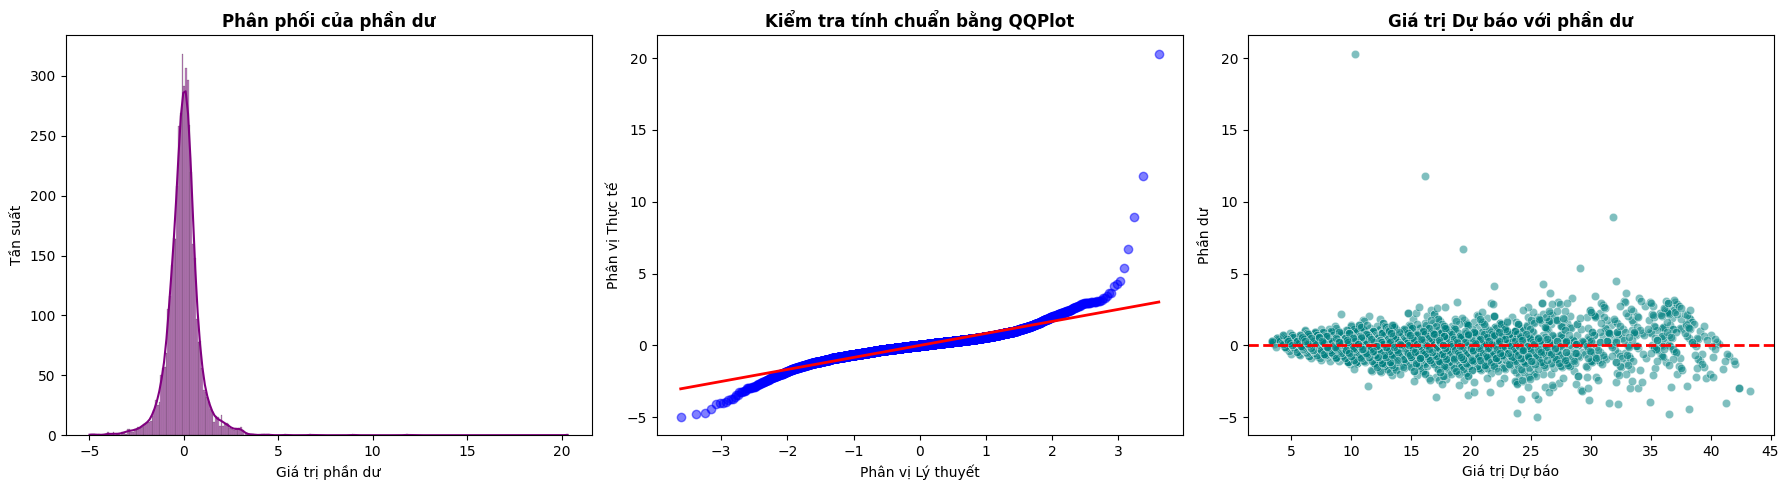

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- DIỄN GIẢI KẾT QUẢ CHO BÁO CÁO ---
1. Hằng số (Intercept): 2.20 USD
   -> Đây là mức giá khởi điểm dự kiến (Giá mở cửa + Phụ phí cố định).
2. Quãng đường: 2.35 USD/dặm
   -> Cứ đi thêm 1 dặm, giá cước tăng thêm từng này.
3. Thời gian: 0.56 USD/phút
   -> Chi phí cho mỗi phút di chuyển/chờ đợi.
4. Cuối tuần (is_weekend): Đã bị loại khỏi mô hình do không có ý nghĩa thống kê.


In [ ]:

# 1. Vẽ bộ 3 đồ thị chẩn đoán
residuals = final_model.resid
fitted = final_model.fittedvalues

# Thiết lập kích thước: 1 hàng, 3 cột
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# HISTOGRAM
sns.histplot(residuals, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Phân phối của phần dư', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Giá trị phần dư', fontsize=10)
ax[0].set_ylabel('Tần suất', fontsize=10) # Đổi chữ "Count" thành "Tần suất"

# Lấy dữ liệu từ probplot chứ không vẽ ngay
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")

# Tự vẽ lại để kiểm soát nhãn trục
ax[1].scatter(osm, osr, color='blue', alpha=0.5)
ax[1].plot(osm, slope * osm + intercept, color='red', linewidth=2)

ax[1].set_title('Kiểm tra tính chuẩn bằng QQPlot', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Phân vị Lý thuyết', fontsize=10)
ax[1].set_ylabel('Phân vị Thực tế', fontsize=10)

# --- BIỂU ĐỒ 3: FITTED VS RESIDUALS ---
sns.scatterplot(x=fitted, y=residuals, ax=ax[2], color='teal', alpha=0.5)
ax[2].axhline(0, color='red', linestyle='--', linewidth=2)

ax[2].set_title('Giá trị Dự báo với phần dư', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Giá trị Dự báo', fontsize=10)
ax[2].set_ylabel('Phần dư', fontsize=10)

plt.tight_layout()
'''
# Lưu ảnh
plt.savefig('bieu_do_phan_du.png', dpi=300)
print("Đã lưu ảnh tiếng Việt: bieu_do_chan_doan_tieng_viet.png")

plt.show()

# Tự động tải về (nếu dùng Colab)
try:
    from google.colab import files
    files.download('bieu_do_chan_doan_tieng_viet.png')
except ImportError:
    pass'''